In [ ]:
from ecg_core.rr_hr_hrv import *
import matplotlib.pyplot as plt
from matplotlib import ticker

ecg = pd.read_parquet('ecg_log_2026-02-21_002056.parquet')

In [2]:
ecg_beats = BeatCalc(ecg)
peaks = ecg_beats.peaks
fs = ecg_beats.fs

# 1) RR（秒）
rr = np.diff(peaks) / fs
t_rr = peaks[1:] / fs

rr_s = pd.Series(rr, index=t_rr, dtype=float)

# 2) 物理边界剔除
rr_s[(rr_s < 0.50) | (rr_s > 2.00)] = np.nan

# 3) 跳变剔除（相邻差分）
drr = rr_s.diff().abs()
rr_s[drr > 0.20] = np.nan

# 4) 可选：再来一个相对跳变（更稳）
rel = (rr_s.diff().abs() / rr_s.shift(1)).abs()
rr_s[rel > 0.25] = np.nan


# 5) 插值（让曲线连续）
rr_clean = rr_s.interpolate(limit=3).dropna()

In [3]:

def hrv_metrics_from_rr(rr_s, *, unit="s"):
    """
    Compute basic HRV metrics from RR intervals.

    Parameters
    ----------
    rr_s : array-like or pd.Series
        RR intervals. Default expected unit is seconds.
        Can contain NaN; will be dropped.
    unit : {"s","ms"}
        Unit of rr_s.

    Returns
    -------
    metrics : dict
        Keys include:
        - n_beats (int)
        - mean_rr_ms, median_rr_ms
        - mean_hr_bpm
        - sdnn_ms
        - rmssd_ms
        - pnn50_pct
        - poincare_sd1_ms, poincare_sd2_ms, sd1_sd2
    """
    rr = np.asarray(rr_s, dtype=float)
    rr = rr[~np.isnan(rr)]
    if rr.size < 3:
        raise ValueError("Need at least 3 RR intervals after NaN removal.")

    # Convert to seconds internally
    if unit == "ms":
        rr_sec = rr / 1000.0
    elif unit == "s":
        rr_sec = rr
    else:
        raise ValueError("unit must be 's' or 'ms'")

    rr_ms = rr_sec * 1000.0
    drr_ms = np.diff(rr_ms)

    mean_rr_ms = float(np.mean(rr_ms))
    median_rr_ms = float(np.median(rr_ms))
    mean_hr_bpm = float(60.0 / np.mean(rr_sec))

    # Time-domain
    sdnn_ms = float(np.std(rr_ms, ddof=1))
    rmssd_ms = float(np.sqrt(np.mean(drr_ms**2)))

    # pNN50
    pnn50_pct = float(100.0 * np.mean(np.abs(drr_ms) > 50.0))

    # Poincaré (standard definitions)
    # SD1 relates to short-term variability; SD2 to long-term.
    sd1_ms = float(np.sqrt(0.5) * np.std(drr_ms, ddof=1))
    sd2_ms = float(np.sqrt(2.0 * sdnn_ms**2 - 0.5 * np.std(drr_ms, ddof=1)**2))
    sd1_sd2 = float(sd1_ms / sd2_ms) if sd2_ms > 0 else np.nan

    return {
        "n_beats": int(rr_ms.size),
        "mean_rr_ms": mean_rr_ms,
        "median_rr_ms": median_rr_ms,
        "mean_hr_bpm": mean_hr_bpm,
        "sdnn_ms": sdnn_ms,
        "rmssd_ms": rmssd_ms,
        "pnn50_pct": pnn50_pct,
        "poincare_sd1_ms": sd1_ms,
        "poincare_sd2_ms": sd2_ms,
        "sd1_sd2": sd1_sd2,
    }


def add_poincare_ellipse(ax, mean_rr_ms, sd1_ms, sd2_ms, n_std=2.0, **kwargs):
    """
    Draw Poincaré ellipse centered at (mean_rr_ms, mean_rr_ms),
    with axes aligned to the identity line, using SD1/SD2.
    n_std controls ellipse size (e.g., 1, 2, 3).
    """
    # Parametric ellipse in SD2-SD1 coordinate frame
    theta = np.linspace(0, 2*np.pi, 400)
    a = n_std * sd2_ms  # along identity line
    b = n_std * sd1_ms  # perpendicular
    u = a * np.cos(theta)
    v = b * np.sin(theta)

    # Rotate back to (RRn, RRn+1) coordinates:
    # identity/perpendicular basis is rotated by 45 degrees
    x_ell = mean_rr_ms + (u - v) / np.sqrt(2)
    y_ell = mean_rr_ms + (u + v) / np.sqrt(2)

    ax.plot(x_ell, y_ell, **kwargs)


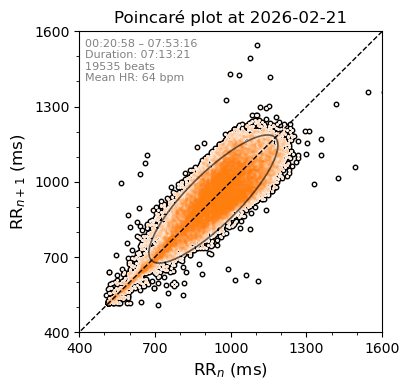

In [5]:
x = rr_clean.to_numpy() * 1000
diag = np.linspace(200, 1600)

metrics = hrv_metrics_from_rr(rr_clean, unit="s")
mean_rr_ms = np.mean(x) 
sd1 = metrics["poincare_sd1_ms"]
sd2 = metrics["poincare_sd2_ms"]

x = rr_clean.to_numpy() * 1000
diag = np.linspace(200, 1600)

fig = plt.figure(figsize=(4.2,4))
ax = plt.gca()

ax.scatter(x[:-1], x[1:], s=5, color="0.0", lw=2)
ax.scatter(x[:-1], x[1:], s=5, color="1.0", lw=0)
ax.scatter(x[:-1], x[1:], s=5, color="C1", lw=0, alpha=0.1)
ax.plot(diag, diag, color='k', linewidth=1, linestyle='--')

ax.set_xlabel("RR$_n$ (ms)", fontsize=12)
ax.set_ylabel("RR$_{n+1}$ (ms)", fontsize=12)

begin_date, begin_time = get_dtime(ecg_beats.begin_time).split()
end_date, end_time = get_dtime(ecg_beats.end_time).split()

if begin_date == end_date:
    ax.set_title(f"Poincaré plot at {begin_date}")
    ax.text(425, 1400,
        f"{begin_time} – {end_time}\nDuration: 07:13:21\n"
        f"{len(rr_clean)} beats\n"
        f"Mean HR: {60/np.mean(rr_clean):.0f} bpm",
        color='gray', fontsize=8
        )
else:
    ax.set_title(f"Poincaré plot\n{begin_date} – {end_date}", loc="left")
    ax.text(425, 1345,
        f"{begin_date} {begin_time} –\n{end_date} {end_time}\nDuration: 07:13:21\n"
        f"Beats: {len(rr_clean)}\n"
        f"Mean HR: {60/np.mean(rr_clean):.0f} bpm",
        color='gray', fontsize=8
        )

ax.set_xlim(400, 1600)
ax.set_ylim(400, 1600)
ax.xaxis.set_major_locator(ticker.LinearLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_major_locator(ticker.LinearLocator(5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(100))



add_poincare_ellipse(
    ax, mean_rr_ms, sd1, sd2,
    n_std=2.0,
    color="k", linewidth=1.2, alpha=0.6
)

plt.tight_layout()

begin_time = ecg['time'].values[0]
begin_dtime = get_dtime_nospace(begin_time)
plt.savefig('ellipse_poincare_%s.jpg'%begin_dtime, dpi=500)


